<a href="https://colab.research.google.com/github/jose-esquivel-dev/Analitica_de_Datos/blob/main/Pr%C3%A1ctica_3/AD_U2_EjemploModeloRegresionLineal_MiaLlanas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**APLICACION DE UN MODELO DE MACHINE LEARNING DE REGRESION LINEAL**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


En esta actividad usarás el archivo de datos `bigMartSales.csv`.

* `Item_Identifier`: ID de producto único
* `Item_Weight`: Peso del producto
* `Item_Fat_Content`: si el producto es bajo en grasa o no
* `Item_Visibility`: el porcentaje del área de exhibición total de todos los productos en una tienda asignado al producto en particular.
* `Item_Type`: La categoría a la que pertenece el producto.
* `Item_MRP`: Precio de venta máximo (precio de lista) del producto
* `Outlet_Identifier`: ID de tienda única
* `Outlet_Establishment_Year`: El año en que se estableció la tienda.
* `Outlet_Size`: El tamaño de la tienda en términos de superficie cubierta.
* `Outlet_Location_Type`: El tipo de ciudad en la que se encuentra la tienda.
* `Outlet_Type`: si el outlet es solo una tienda de comestibles o algún tipo de supermercado.

* **`Item_Outlet_Sales`**: Ventas del producto en la tienda concreta. Ésta es la variable de resultado que se va a predecir.

In [2]:
# Librerías para manipulación de datos
import numpy as np
import pandas as pd

# Librerías para visualización
import seaborn as sns
import matplotlib.pyplot as plt


# Librerías para preprocesamiento e ing de características
from sklearn.impute import SimpleImputer #sirve para rellenar los datos faltantes (imputar)
                    #Cuando tienes datos con valores nulos (NaN), permite remplazarlos con mean, median, most_frecuent, constant)


from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
              #MinMaxScaler, normaliza los datos numericos dentro de un rango [0,1]
                    #ayuda a que los modelos ML funcionen mejor, reduce la influencia de variables con escalas muy diferentes

              #OneHOTEncoder, convierte variables categoricas en una representacion binaria
                    #Algoritmo de ML no entienden texto. Este enconder convierte cada columna Categorica en na BInaria (0 y 1)

# Librerías para la canalización (pipeline)
    #es una forma ordenada de Encadenar pasos de preprocesamiento y modelado, forma que puedas tratar tus datos y entrenar un modelo
    #todo en una sola estructura, sin repetir codigo ni cometer errores por hacer pasos manuales

from sklearn.compose import ColumnTransformer, make_column_selector
      #ColumnTransformer, aplica diferentes transformaciones a diferentes columnas de tu conjunto de datos
          #dado que NO TODAS las columnas necesitan el mismo tratamiento
          #Columnas numericas, se escalan con MinMAxScaler
          #Columnas categoricas se codifican con OneHOtEncoder

      #make_column_selector, selecciona automaticamente columnas numericas o categoricas del DF segun su tipo de datos
          #Para no escribir los nombres de las columnas manualmente. Especialmente util cuando tenemos muchas columnas y
          #queremos seleccionar todas las numericas o todas las categoricas sin necesidad de enlistarlas

from sklearn.pipeline import make_pipeline
      #permite encadenar los pasos secuenciales de transformacion y modelado (Escalado - Codificacion - modelado)
      #Se evita tener que hacer transformaciones por separado y nos asegura que se aplicacn en el orden correcto, tanto al entrenar como al hacer predicciones


# Librerías para la regresión
from sklearn.linear_model import LinearRegression
      #modelo de Regresion Lineal clasico de Scikit-learn
      #ENTRENA UN MODELO DE REGRESION LINEAL PARA PREDECIR VALORES NUMERICOS
      #se utiliza para predecir valores numericos en funcion de una variable o mas variables independientes.
      #Busca una linea recta que mejor se ajuste a los datos

from sklearn.metrics import mean_squared_error, mean_squared_error, r2_score
      #mean_squared_error(MSE), la media de los cuadrados de las diferencias entre los valores reales y los predichos
      #EVALUA EL MODELO MIDIENDO EL ERROR CUADRATICO MEDIO
      #Cuanto mas bajo el MSE, mejor es el modelo
      #tienen las mismas unidades que la variable objetivo al elevar al cuadrado, lo que penaliza los errores

      #Coeficiente de determinacion (r2_score), indica que la proporcion de la varianza en la variable dependiente se puede explciar por las variables independientes
      #EVALUA EL MODELO INDICANDO QUE TAMBIEN EXPLICA LA VARIACION DE LOS DATOS
      #su valor va entre 0 y 1
      #r2_score=1, el modelo predice de manera perfecta
      #r2_scores=0, el modelo no explica nada mejor que una media

Descarga el archivo: `bigMartSales.csv` y guarda, en un dataframe (`sales_df`), todos sus registros.

In [3]:
sales_df = pd.read_csv('/content/drive/MyDrive/Análitica de Datos /bigMartSales.csv')
sales_df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [ ]:
print("Media:\n", sales_df.mean(numeric_only=True))
print("\nMediana:\n", sales_df.median(numeric_only=True))
print("\nModa:\n", sales_df.mode().iloc[0])

Media:
 Item_Weight                    12.857645
Item_Visibility                 0.066132
Item_MRP                      140.992782
Outlet_Establishment_Year    1997.831867
Item_Outlet_Sales            2181.288914
dtype: float64

Mediana:
 Item_Weight                    12.600000
Item_Visibility                 0.053931
Item_MRP                      143.012800
Outlet_Establishment_Year    1999.000000
Item_Outlet_Sales            1794.331000
dtype: float64

Moda:
 Item_Identifier                              FDG33
Item_Weight                                  12.15
Item_Fat_Content                           Low Fat
Item_Visibility                                0.0
Item_Type                    Fruits and Vegetables
Item_MRP                                  172.0422
Outlet_Identifier                           OUT027
Outlet_Establishment_Year                   1985.0
Outlet_Size                                 Medium
Outlet_Location_Type                        Tier 3
Outlet_Type            

In [ ]:
print("--- DISPERSIÓN Y VARIABILIDAD ---")
display(sales_df.describe()) # Incluye min, max, desviación estándar y cuartiles
print("Desviación estándar:\n", sales_df.std(numeric_only=True))

print("\n--- FORMA (Asimetría y Curtosis) ---")
print("Asimetría (Skew):\n", sales_df[['person_age', 'loan_int_rate']].skew())
print("\nCurtosis (Kurt):\n", sales_df[['person_age', 'loan_int_rate']].kurt())

--- DISPERSIÓN Y VARIABILIDAD ---


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


Desviación estándar:
 Item_Weight                     4.643456
Item_Visibility                 0.051598
Item_MRP                       62.275067
Outlet_Establishment_Year       8.371760
Item_Outlet_Sales            1706.499616
dtype: float64

--- FORMA (Asimetría y Curtosis) ---


KeyError: "None of [Index(['person_age', 'loan_int_rate'], dtype='object')] are in the [columns]"

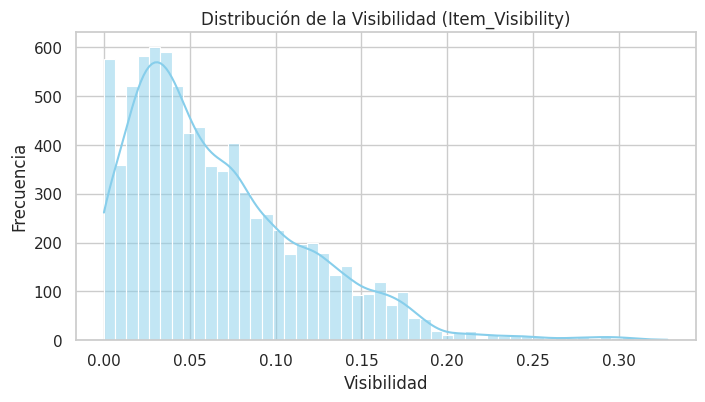

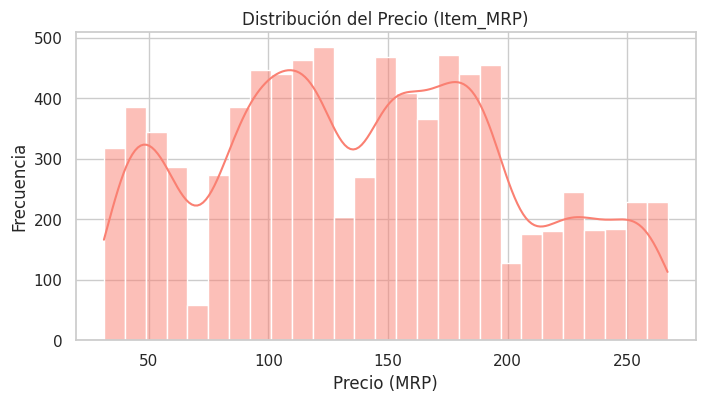

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo del gráfico
sns.set_theme(style="whitegrid")

# 1. Gráfico para la variable 'Item_Visibility'
plt.figure(figsize=(8, 4))
sns.histplot(sales_df['Item_Visibility'], kde=True, color='skyblue')
plt.title('Distribución de la Visibilidad (Item_Visibility)')
plt.xlabel('Visibilidad')
plt.ylabel('Frecuencia')
plt.show()

# 2. Gráfico para la variable 'Item_MRP'
plt.figure(figsize=(8, 4))
sns.histplot(sales_df['Item_MRP'], kde=True, color='salmon')
plt.title('Distribución del Precio (Item_MRP)')
plt.xlabel('Precio (MRP)')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
print("--- RESUMEN ESTADÍSTICO Y CUARTILES ---")
display(sales_df.describe())

print("\n--- DESVIACIÓN ESTÁNDAR ---")
display(sales_df.std(numeric_only=True))

--- RESUMEN ESTADÍSTICO Y CUARTILES ---


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800



--- DESVIACIÓN ESTÁNDAR ---


,0
Item_Weight,4.643456
Item_Visibility,0.051598
Item_MRP,62.275067
Outlet_Establishment_Year,8.371760
Item_Outlet_Sales,1706.499616


In [ ]:
print("--- ASIMETRÍA (Skewness) ---")
print(sales_df[['Item_Visibility', 'Item_MRP']].skew())

print("\n--- CURTOSIS ---")
print(sales_df[['Item_MRP']].kurt())

--- ASIMETRÍA (Skewness) ---
Item_Visibility    1.167091
Item_MRP           0.127202
dtype: float64

--- CURTOSIS ---
Item_MRP   -0.889769
dtype: float64


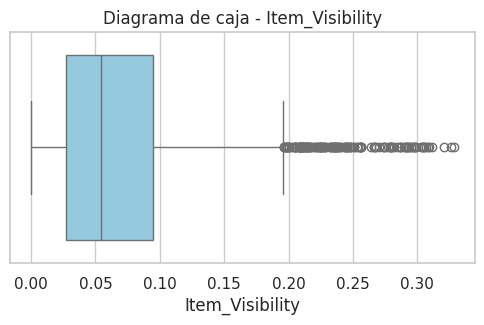

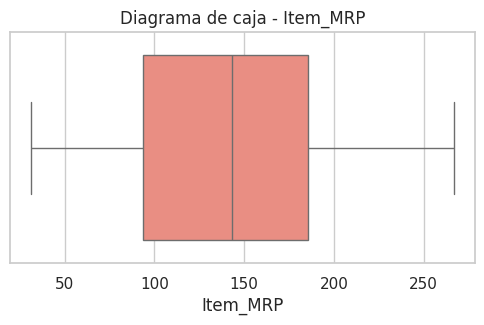

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 3))
sns.boxplot(x=sales_df['Item_Visibility'], color='skyblue')
plt.title('Diagrama de caja - Item_Visibility')
plt.show()

plt.figure(figsize=(6, 3))
sns.boxplot(x=sales_df['Item_MRP'], color='salmon')
plt.title('Diagrama de caja - Item_MRP')
plt.show()

In [ ]:
percentile_25 = sales_df["Item_Visibility"].quantile(0.25)
percentile_75 = sales_df["Item_Visibility"].quantile(0.75)
iqr = percentile_75 - percentile_25

upper_limit = percentile_75 + 1.5 * iqr
lower_limit = percentile_25 - 1.5 * iqr

# Filtrar los outliers de visibilidad
outliers_visibility = sales_df[(sales_df["Item_Visibility"] < lower_limit) | (sales_df["Item_Visibility"] > upper_limit)]
print(f"Número de outliers encontrados en Item_Visibility: {len(outliers_visibility)}")

Número de outliers encontrados en Item_Visibility: 144


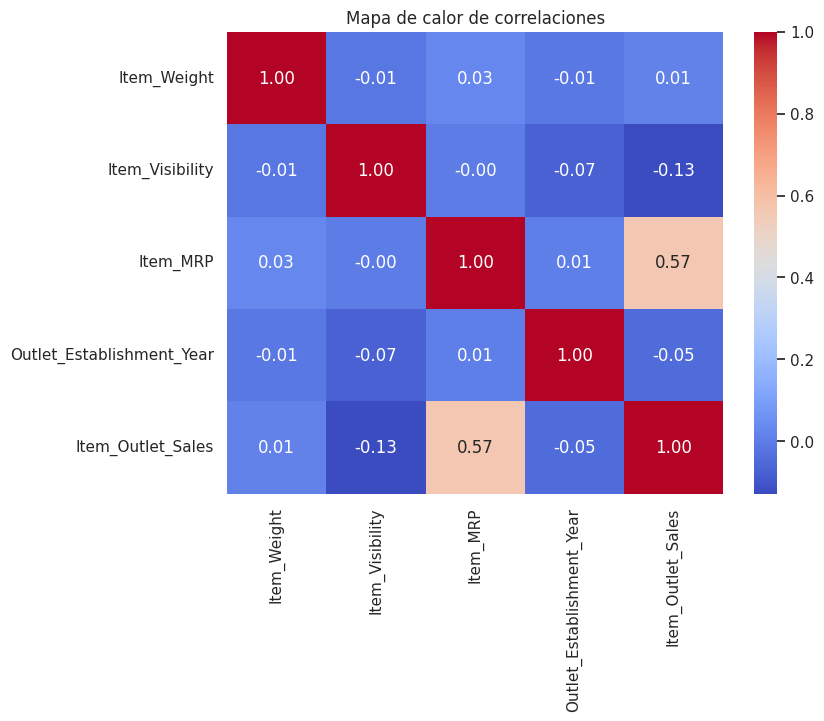

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(sales_df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de calor de correlaciones')
plt.show()

ANALISIS DE DATOS

In [ ]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [ ]:
# Determinando la cantidad de valores únicos por columna
sales_df.nunique()

Item_Identifier              1559
Item_Weight                   415
Item_Fat_Content                5
Item_Visibility              7880
Item_Type                      16
Item_MRP                     5938
Outlet_Identifier              10
Outlet_Establishment_Year       9
Outlet_Size                     3
Outlet_Location_Type            3
Outlet_Type                     4
Item_Outlet_Sales            3493
dtype: int64

Como las variables `Item_Identifier` y `Outlet_Identifier` son solo variables de ID, asumimos que no tienen ningún poder predictivo para predecir la variable dependiente: `Item_Outlet_Sales`.

In [ ]:
sales_df.drop(['Item_Identifier','Outlet_Identifier'], axis=1, inplace=True)

In [ ]:
# Estadísticas descriptivas de las variables numéricas
sales_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Item_Weight,7060.0,12.857645,4.643456,4.555,8.773750,12.600000,16.850000,21.350000
Item_Visibility,8523.0,0.066132,0.051598,0.000,0.026989,0.053931,0.094585,0.328391
Item_MRP,8523.0,140.992782,62.275067,31.290,93.826500,143.012800,185.643700,266.888400
Outlet_Establishment_Year,8523.0,1997.831867,8.371760,1985.000,1987.000000,1999.000000,2004.000000,2009.000000
Item_Outlet_Sales,8523.0,2181.288914,1706.499616,33.290,834.247400,1794.331000,3101.296400,13086.964800


In [ ]:
# Estadísticas descriptivas de las variables de texto
sales_df.describe(include = 'object').T

,count,unique,top,freq
Item_Fat_Content,8523,5,Low Fat,5089
Item_Type,8523,16,Fruits and Vegetables,1232
Outlet_Size,6113,3,Medium,2793
Outlet_Location_Type,8523,3,Tier 3,3350
Outlet_Type,8523,4,Supermarket Type1,5577


In [ ]:
# Se hace una lista de variables numéricas y otra de categóricas.
num_cols = sales_df.select_dtypes(include=np.number).columns.tolist()
cat_cols = sales_df.select_dtypes(exclude=np.number).columns.tolist()

In [ ]:
# Recuento de cada categoría única en las variables categóricas
for column in cat_cols:
    print(column)
    print(sales_df[column].value_counts())
    print('-' * 50)

Item_Fat_Content
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64
--------------------------------------------------
Item_Type
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64
--------------------------------------------------
Outlet_Size
Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64
--------------------------------------------------
Outlet_Location_Type
Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388

In [ ]:
# Se determinan porcentaje de nulos por columna
sales_df.isnull().mean() * 100

Item_Weight                  17.165317
Item_Fat_Content              0.000000
Item_Visibility               0.000000
Item_Type                     0.000000
Item_MRP                      0.000000
Outlet_Establishment_Year     0.000000
Outlet_Size                  28.276428
Outlet_Location_Type          0.000000
Outlet_Type                   0.000000
Item_Outlet_Sales             0.000000
dtype: float64

In [ ]:
# Dispersión (Mínimo, máximo, desviación estándar y cuartiles)
print("Mínimo:\n", sales_df.min(numeric_only=True))
print("\nMáximo:\n", sales_df.max(numeric_only=True))
print("\nDesviación estándar:\n", sales_df.std(numeric_only=True))
display(sales_df.describe())

# Forma (Asimetría y Curtosis)
print("\nAsimetría (Skewness):\n", sales_df.skew(numeric_only=True))
print("\nCurtosis:\n", sales_df.kurt(numeric_only=True))

Mínimo:
 Item_Weight                     4.555
Item_Visibility                 0.000
Item_MRP                       31.290
Outlet_Establishment_Year    1985.000
Item_Outlet_Sales              33.290
dtype: float64

Máximo:
 Item_Weight                     21.350000
Item_Visibility                  0.328391
Item_MRP                       266.888400
Outlet_Establishment_Year     2009.000000
Item_Outlet_Sales            13086.964800
dtype: float64

Desviación estándar:
 Item_Weight                     4.643456
Item_Visibility                 0.051598
Item_MRP                       62.275067
Outlet_Establishment_Year       8.371760
Item_Outlet_Sales            1706.499616
dtype: float64


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800



Asimetría (Skewness):
 Item_Weight                  0.082426
Item_Visibility              1.167091
Item_MRP                     0.127202
Outlet_Establishment_Year   -0.396641
Item_Outlet_Sales            1.177531
dtype: float64

Curtosis:
 Item_Weight                 -1.227766
Item_Visibility              1.679445
Item_MRP                    -0.889769
Outlet_Establishment_Year   -1.205694
Item_Outlet_Sales            1.615877
dtype: float64


**Análisis univariado de variables numéricas**

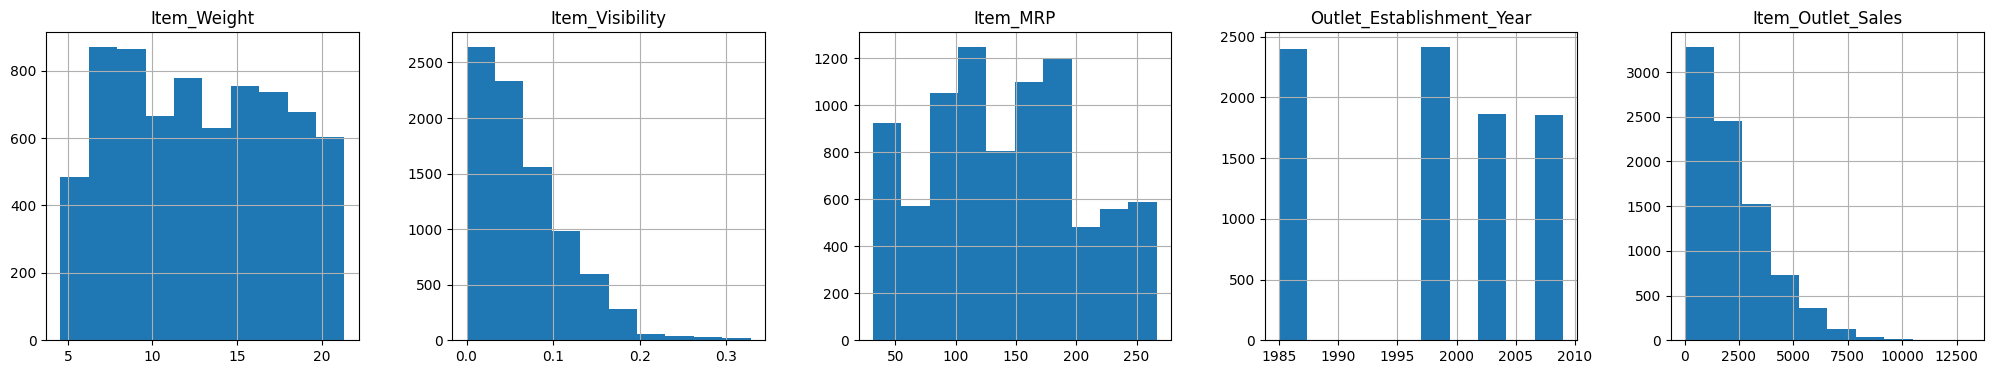

In [ ]:
sales_df.hist(figsize=(25,4), layout=(1,5))
plt.show()

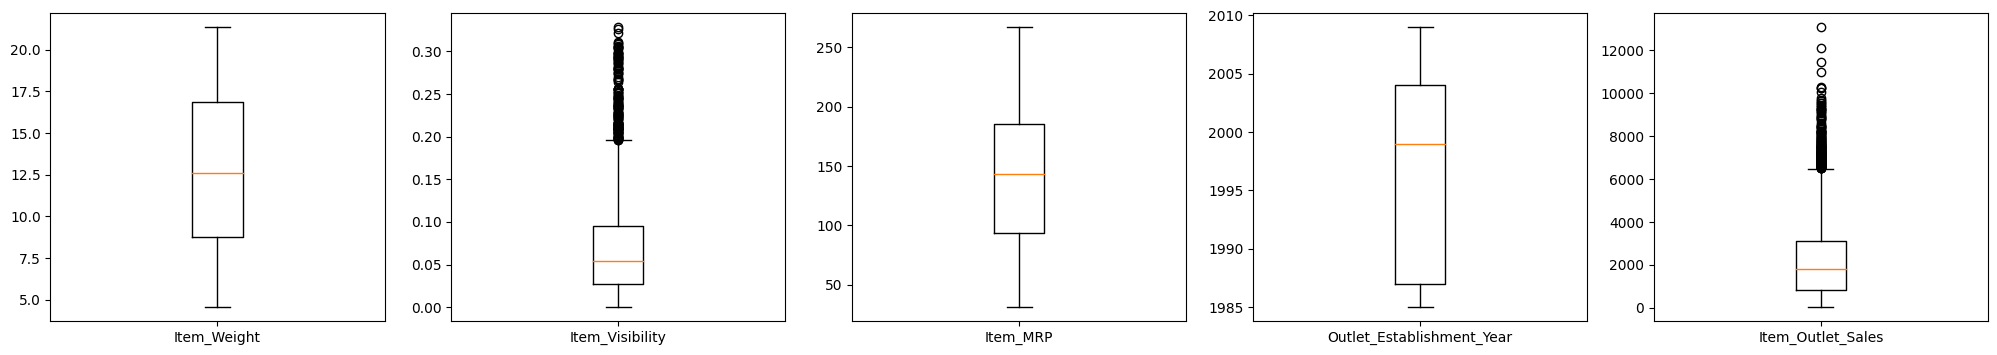

In [ ]:
fig, axes = plt.subplots(1,5, figsize=(25,4))
axes = axes.ravel()
for col, ax in zip(sales_df[num_cols], axes):
  ax.boxplot(sales_df[col].dropna(), labels=[f'{col}'])

In [4]:
sales_raw = pd.read_csv('/content/drive/MyDrive/Análitica de Datos /bigMartSales.csv')
vis = sales_raw['Item_Visibility']
print('Sesgo de Item_Visibility:', round(vis.skew(), 3))

Sesgo de Item_Visibility: 1.167


In [6]:
n= (vis == 0).sum()
print('Registros con visibilidad 0:', n)
print('Porcentaje del total:', round(n / len(vis) * 100, 2), '%')

Registros con visibilidad 0: 526
Porcentaje del total: 6.17 %


In [7]:
con_ceros = sales_raw.groupby('Item_Identifier')['Item_Visibility'].apply(lambda s: (s == 0).any())
print('Productos con al menos un cero:', con_ceros.sum(), 'de', len(con_ceros))

producto = con_ceros[con_ceros].index[0]
sales_raw[sales_raw['Item_Identifier'] == producto][['Item_Identifier', 'Outlet_Identifier', 'Item_Visibility']]

Productos con al menos un cero: 446 de 1559


,Item_Identifier,Outlet_Identifier,Item_Visibility
118,DRA12,OUT017,0.041178
1197,DRA12,OUT045,0.000000
1245,DRA12,OUT013,0.040912
1693,DRA12,OUT035,0.000000
7467,DRA12,OUT018,0.041113
8043,DRA12,OUT010,0.068535


In [8]:
print('Mínimo:', vis.min(), '| Máximo:', vis.max())
print('Valores negativos:', (vis < 0).sum())
print('Valores mayores a 1:', (vis > 1).sum())

Mínimo: 0.0 | Máximo: 0.328390948
Valores negativos: 0
Valores mayores a 1: 0


In [9]:
sales_raw.groupby('Outlet_Identifier')['Item_Visibility'].sum().round(2)

,Item_Visibility
Outlet_Identifier,
OUT010,56.31
OUT013,55.88
OUT017,56.83
OUT018,56.62
OUT019,57.26
OUT027,54.80
OUT035,56.97
OUT045,56.18
OUT046,56.23


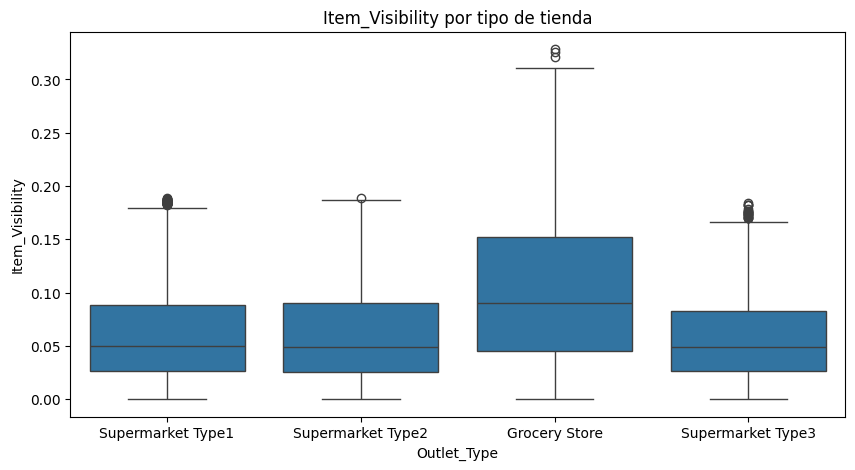

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Outlet_Type', y='Item_Visibility', data=sales_raw)
plt.title('Item_Visibility por tipo de tienda')
plt.show()

**Análisis univariado de variables categóricas**

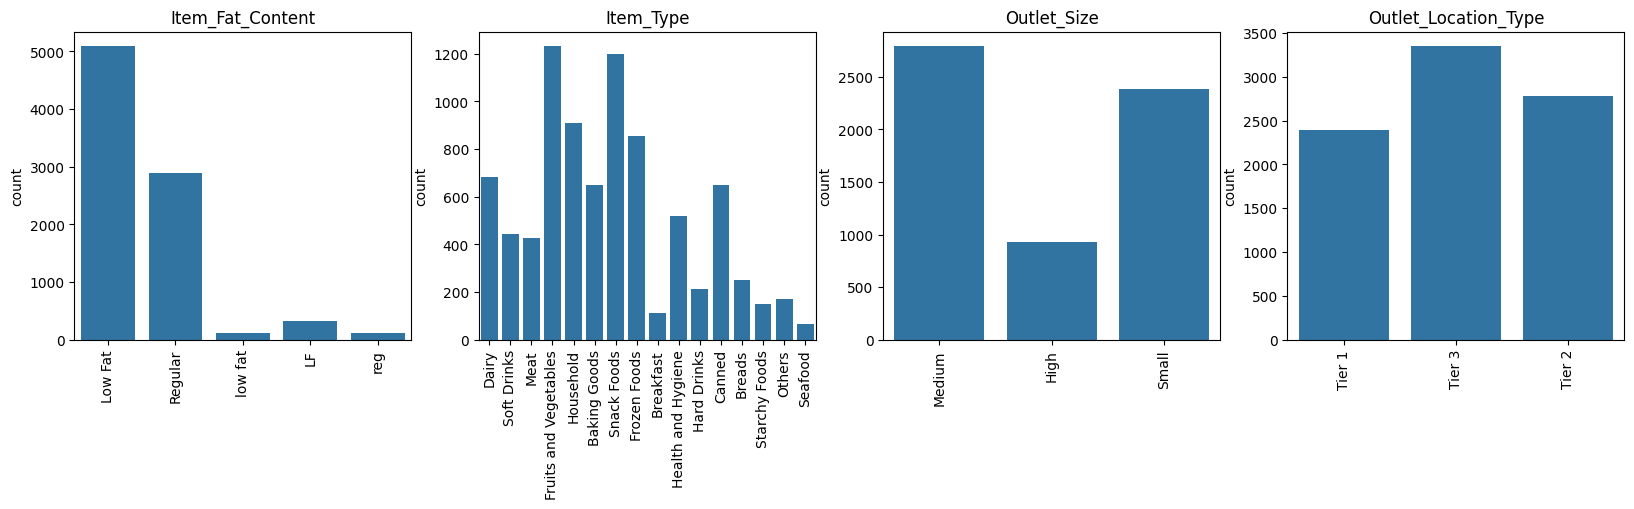

In [ ]:
fig, axes = plt.subplots(1,4, figsize=(20,4))
axes = axes.ravel()
for col, ax in zip(sales_df[cat_cols], axes):
  sns.countplot(x=sales_df[col], ax=ax)
  ax.set(title=f'{col}', xlabel=None)
  ax.tick_params(axis='x',rotation=90)

En `Ite_Fat_Content` hay categorías expresadas de diferente forma:
*   Low Fat = low fat = LF
*   Regular = reg

Se unifica, para sólo dejar dos valores: Low Fat y Regular



In [ ]:
sales_df['Item_Fat_Content'] = sales_df['Item_Fat_Content'].apply(lambda x: 'Low Fat' if x == 'low fat' or x == 'LF' else x)
sales_df['Item_Fat_Content'] = sales_df['Item_Fat_Content'].apply(lambda x: 'Regular' if x == 'reg' else x)

<Axes: xlabel='Item_Fat_Content', ylabel='count'>

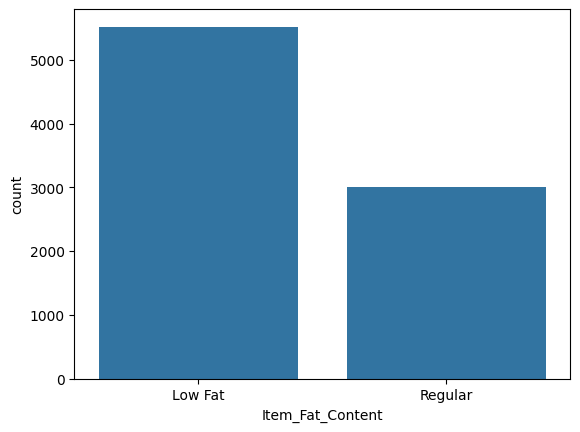

In [ ]:
sns.countplot(x=sales_df['Item_Fat_Content'])

**Análisis bivariado**

<Axes: >

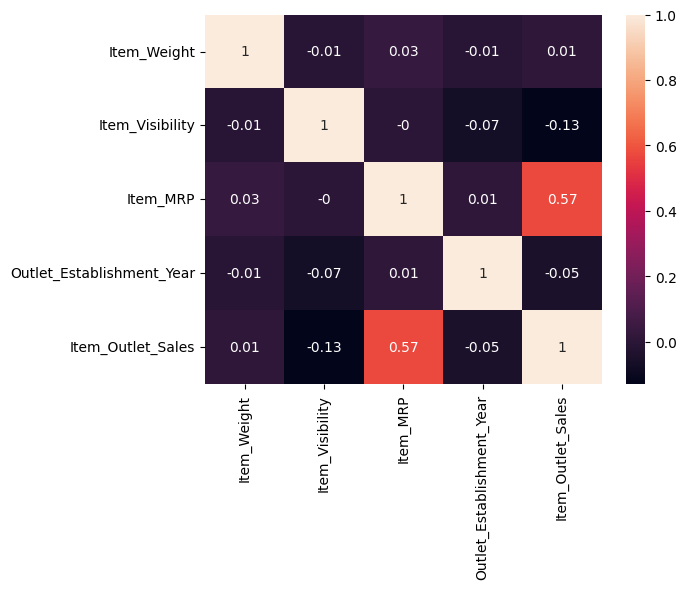

In [ ]:
sns.heatmap(round(sales_df.corr(numeric_only=True),2), annot = True)

Del gráfico anterior, parece que solo la variable independiente `Item_MRP` tiene una relación lineal moderada con la variable dependiente `Item_Outlet_Sales`. Se verifica con diagramas de dispersión.

<Axes: xlabel='Item_MRP', ylabel='Item_Outlet_Sales'>

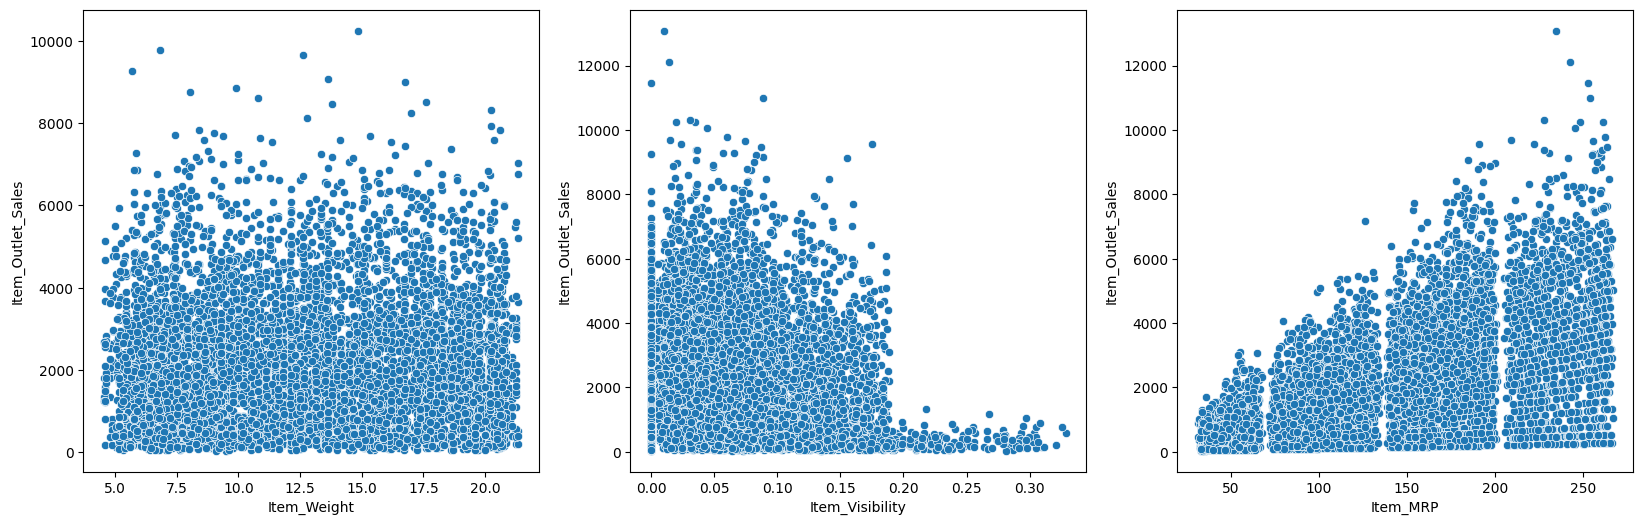

In [ ]:
fig, axes = plt.subplots(1, 3, figsize = (20, 6))
sns.scatterplot(x='Item_Weight', y='Item_Outlet_Sales', data=sales_df, ax=axes[0])
sns.scatterplot(x='Item_Visibility', y='Item_Outlet_Sales', data=sales_df, ax=axes[1])
sns.scatterplot(x='Item_MRP', y='Item_Outlet_Sales', data=sales_df, ax=axes[2])

Se crea una nueva característica `Outlet_Age` que indica la antigüedad del outlet.

In [ ]:
from datetime import date #permite trabajar con fechas
#date.today().year, obtiene el año actual
#sales_df['Outlet_Establishment_year'], columna que tinee el año que se fundo cada tienda
sales_df['Outlet_Age'] = date.today().year - sales_df['Outlet_Establishment_Year'] #calcula la edad de cada tienda en años

sales_df.drop('Outlet_Establishment_Year', axis = 1, inplace=True) #elimina la columan original
    #se elimina porque ya no es necesaria, ya que fue transformada auna forma mas util para el modelo
    #ayuda a reducir la dimensionalidad del dataset y evita redundancia

    #axis=1, indica que se elimnara una COLUMNA (en lugar de una fila)
    #inplace=true, guarda cambios directamente en el df

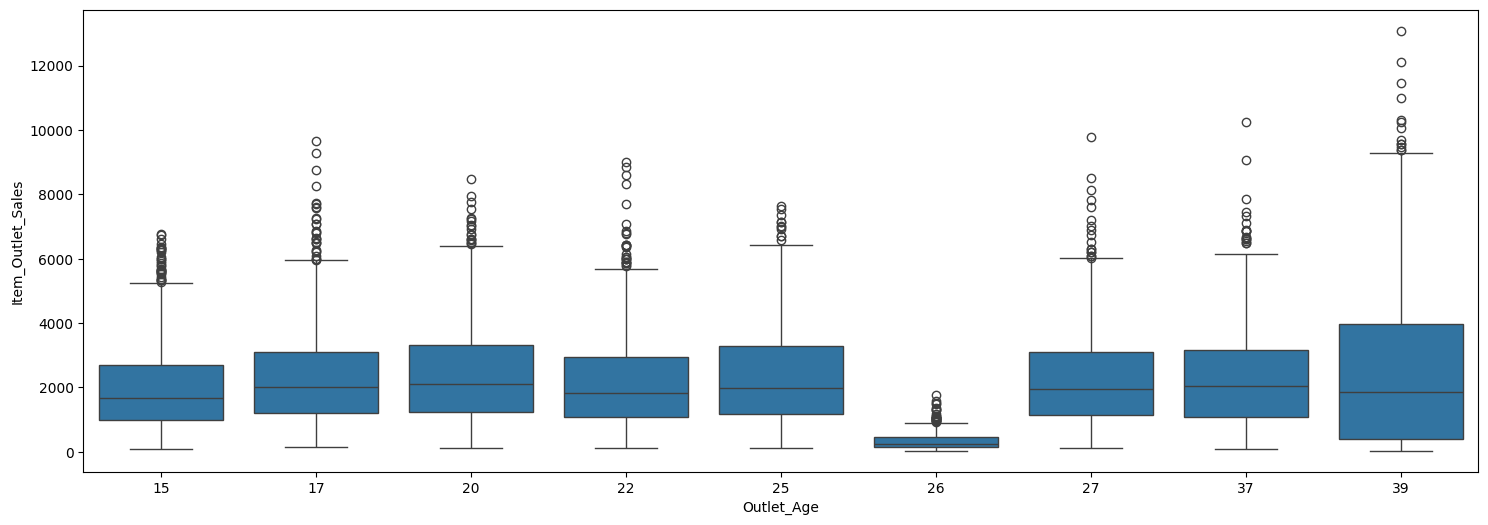

In [ ]:
fig = plt.figure(figsize = (18, 6))
sns.boxplot(x = 'Outlet_Age', y = 'Item_Outlet_Sales', data = sales_df);

**INCIO MODELO MACHINE LEARNING**

Aplicación de la corrección en sales_df

Detección de Valores Atípicos (Outliers con IQR)

In [15]:
percentile_25 = sales_df["Item_MRP"].quantile(0.25) # Calcula el primer cuartil (Q1) de la columna de precios.
percentile_75 = sales_df["Item_MRP"].quantile(0.75) # Calcula el tercer cuartil (Q3) de la columna de precios.

iqr = percentile_75 - percentile_25 # Calcula el Rango Intercuartil (IQR).

upper_limit = percentile_75 + 1.5 * iqr # Define el límite superior para outliers.
lower_limit = percentile_25 - 1.5 * iqr # Define el límite inferior para outliers.

IQR_outliers = sales_df[(sales_df["Item_MRP"] < lower_limit) | (sales_df["Item_MRP"] > upper_limit)] # Filtra las filas atípicas.
IQR_outliers # Muestra el resultado.

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales


Análisis Bivariante y Correlación



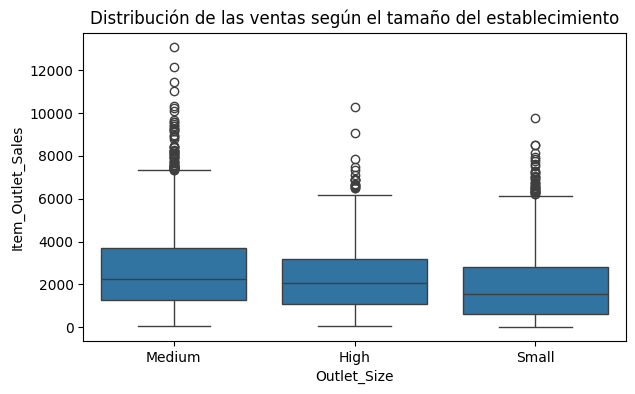

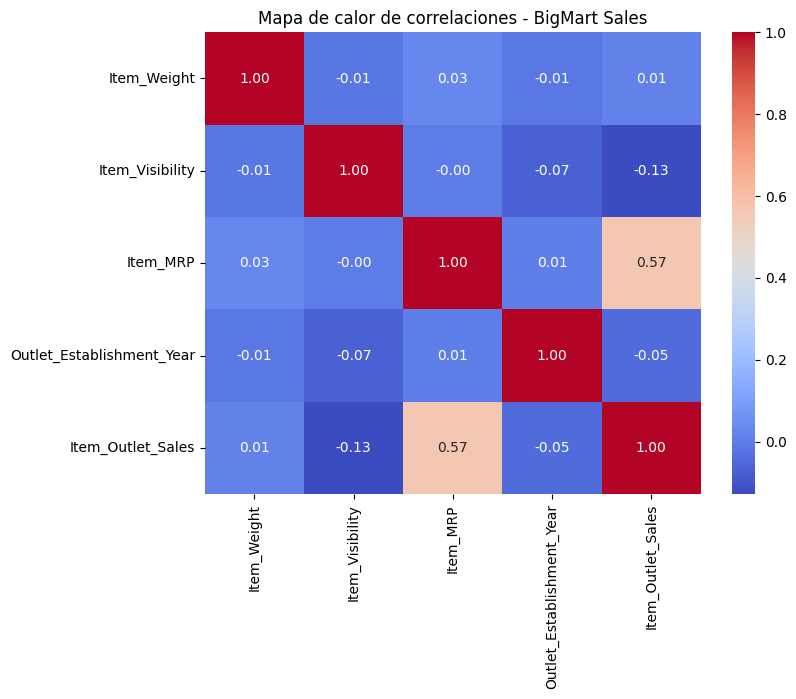

In [16]:
# Boxplot comparativo con columnas reales de sales_df
plt.figure(figsize=(7, 4))
sns.boxplot(x='Outlet_Size', y='Item_Outlet_Sales', data=sales_df)
plt.title('Distribución de las ventas según el tamaño del establecimiento')
plt.show()

# Mapa de calor de correlaciones para sales_df
plt.figure(figsize=(8, 6))
sns.heatmap(sales_df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de calor de correlaciones - BigMart Sales')
plt.show()

INGENIERIA DE CARACTERISTICAS

Se especifican cuales seran las variables de entrada 'X' (Caracteristica) y cual sera la varible predictora 'y' (variable salida o
tambien Objetivo)

In [ ]:
# Se separan las variables del dataframe: en X quedan los predictores y en y la variable de respuesta o salida (Item_Outlet_Sales).
X = sales_df.drop('Item_Outlet_Sales', axis = 1) #variables de entrada - Caracteristica
y = sales_df['Item_Outlet_Sales'] #variable salida -variable predictora - Objetivo

**PARTICION DEL CONJUNTO DE DATOS**

In [ ]:
# Se divide el conjunto en entrenamiento y prueba (80:20)
#80% conjunto de entrenamiento(train)
#20% para el conjunto de prueba (test)

from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(X,#variable entrada
                                                y,#variable salida o predictora
                                                train_size=0.8, # tama;o conjunto entrenamiento
                                                random_state=1) #para mantener mismo conjunto de datos

PROCESAMIENTO

**CANALIZACION (PIPELINE)**

In [ ]:
# Como se aplicará más de un transformador y de manera diferenciada (numéricas y categóricas reciben diferentes tratamientos),
# hay que crear pipelines (aquí se nombraron como: num_pipeline y cat_pipeline) para transformar las columnas

# Si sólo fuera un transformador en cada tipo de variable, no sería necesario crer num_pipeline ni cat_pipeline.
# El transformador único podría ir directamente en el ColumnTransformer que aparece abajo
#PARA VARIABLES NUMERICAS
num_pipeline = make_pipeline(SimpleImputer(strategy='median'), MinMaxScaler())
      #Rellena valores faltantes con la media
      #aplica escalado MinMaxScaler, para que todas los valores numericos esten en el rango [0,1]


#PARA VARIABLES CATEGORICAS
cat_pipeline = make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
      #Rellena valores faltantes con la categoria mas frecuente
      #Convierte categorias en columnas binarias (0,1) con OneHOt

        #parametros de OneHot
          #drop='first', evita la trampa multicolinealidad, eliminando la primer categoria
                #Multicolaniedad- se refiere cuando se da la situacion que dos o mas columnas en un modelo de regresion estan altamente correlacionadas entre si.
                    #es decir, que el modelo no distinga cual es 'y' (variable predictora)
                    #esta alta correlacion puede generar problemas de ajuste del modelo.
                    #si nos variables (columnas), son muy similares, el modelo no puede distinguir cual de ellas tiene mayor influencia en X (variables de entrada)

          #handle_unknown='ignore', ignora nuevas categorias que no se vieron durante el entrenamiento (evita errores de produccion)
          #sparse_output=False, devuelve matriz densa, util si vas a convertir el resultado a un DF)

#UNE PREPROCESAMIENTOS
preprocessing = ColumnTransformer([
    ('num', num_pipeline, make_column_selector(dtype_include=np.number)), #detecta TODAS columnas numericas                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     , make_column_selector(dtype_include=np.number)),
    ('cat', cat_pipeline, make_column_selector(dtype_include=object))])   #detecta TODAS columnas categoricas

In [ ]:
# Esto no es necesario, pero lo incluyo para que se visualicen los cambios que produce el pipeline "preprocessing" creado anteriormente
# Nótese que Xtrain queda con 27 columnas después del procesamiento, es decir, se utilizarán 27 predictores en el modelo (4 numéricos y 23 categóricos)

Xtrain_prepared = preprocessing.fit_transform(Xtrain)
Xtrain_prepared_df = pd.DataFrame(Xtrain_prepared, columns=preprocessing.get_feature_names_out(), index=Xtrain.index)
Xtrain_prepared_df

,num__Item_Weight,num__Item_Visibility,num__Item_MRP,num__Outlet_Age,cat__Item_Fat_Content_Regular,cat__Item_Type_Breads,cat__Item_Type_Breakfast,cat__Item_Type_Canned,cat__Item_Type_Dairy,cat__Item_Type_Frozen Foods,...,cat__Item_Type_Snack Foods,cat__Item_Type_Soft Drinks,cat__Item_Type_Starchy Foods,cat__Outlet_Size_Medium,cat__Outlet_Size_Small,cat__Outlet_Location_Type_Tier 2,cat__Outlet_Location_Type_Tier 3,cat__Outlet_Type_Supermarket Type1,cat__Outlet_Type_Supermarket Type2,cat__Outlet_Type_Supermarket Type3
1945,0.821375,0.272069,0.681925,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1720,0.761834,0.511783,0.615374,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1954,0.330158,0.164095,0.824788,0.083333,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
1919,0.374814,0.496066,0.312702,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2461,0.155701,0.181846,0.423207,0.208333,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2895,0.479012,0.844906,0.531008,1.000000,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7813,0.479012,0.542624,0.100619,1.000000,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
905,0.791605,0.200402,0.500067,0.500000,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
5192,0.300387,0.151094,0.054833,0.458333,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


**APLICA PREPROCESAMIENTO ANTERIOR PARA EL**

**ENTRENAMIENTO DEL MODELO REGRESION LINEAL**

In [ ]:
# Se crea el pipeline para la predicción, que incluye el de procesamiento creado anteriormente y la regresión lineal

#CREA PIPELINE
lr_model = make_pipeline(preprocessing, LinearRegression())
    #PREPROCESING, procesa los datos (relleno de nulos, escalado (minMaxScaler), codificacion (OneHOtEnconder))
    #LinearRegresion, aplica modelo de regresion lineal a los datos ya entrenados

#ENTRENA Y AJUSTA TODO EL PIPELINE CON LOS DATOS DE ENTRENAMIENTO
lr_model.fit(Xtrain, ytrain)
    #primero transforma Xtrain con el preprocesador
    #luego entrena el modelo de LinearRegresion() con las variables transformadas y la variable objetivo ytrain

#APLICA PIPELINE A LOS DATOS DE PRUEBA
predictions = lr_model.predict(Xtest)
  #primero transforma con el mismo preprocesador (usando los parametros aprendidos en fit)
  #despues realiza predicciones con el modelo entrenado

#CALCULA VALOR RMSE ENTRE VALORES REALES (ytest) y los valores predichos por el modelo (Predictions)
print('The Root Mean Square Error (RMSE) is:', mean_squared_error(ytest, predictions, squared=False))
#RMSE nos dice en promedio cuanto se equivoco tu modelo al predecir, en las mismas unidades que la variable objetivo

#esta metrica indica que proporcion de la variacion de la variable dependiente (ytest) es explicada por el modelo
print('The R square (R2) is:', r2_score(ytest, predictions))
#r2= 1, prediccion perfecta
#r2= 0, el modelo no explica mejor que un promedio
#r2<0, el modelo es peor

The Root Mean Square Error (RMSE) is: 1144.3827848578724
The R square (R2) is: 0.5582080574611583


RMSE = 1144.38, significa que el modelo se equivoca por unas 1144.38 unidades.

r2 =0.558, significa que elmodelo explcia el 55.8% de la variabilidad de los datos, el 42% restante, no lo puede explicar (puede deberse al ruido, datos faltantes, variables importantes no incluidas), o hacer uso de otro tipo de transformaciones de variables.

El resultado obtenido por el modelo de regresion lineal no es excelente, debido a que esta haciendo predicciones con un error moderado y explica poco mas de la mitad del comportamiento de la variable objetivo

Lo que seguiría es hacer más transformaciones para mejorar el resultado. Por ejemplo:

* Aplicar una transformación (log, box-cox,...) para hacer que la distribución de `Item_Visibility` tenga una forma más normal, porque está sesgada.

* Usar StandarScaler o RobustScaler en lugar de MinMax.
* Aplicar OrdinalEncoder a algunas categóricas, en lugar de OneHotEncoder.

In [ ]:
# Se puede tener acceso a los pasos ejecutados en el pipeline
lr_model.named_steps

{'columntransformer': ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('simpleimputer',
                                                   SimpleImputer(strategy='median')),
                                                  ('minmaxscaler',
                                                   MinMaxScaler())]),
                                  <sklearn.compose._column_transformer.make_column_selector object at 0x79b984bf35e0>),
                                 ('cat',
                                  Pipeline(steps=[('simpleimputer',
                                                   SimpleImputer(strategy='most_frequent')),
                                                  ('onehotencoder',
                                                   OneHotEncoder(drop='first',
                                                                 handle_unknown='ignore',
                                                                 sparse_output=False))])

In [ ]:
# Una vez ubicado en un paso, por ejemplo en la regresión lineal ('linearregression'), se puede tener acceso a sus atributos
# Para mostrar la intercepción o beta_0
lr_model.named_steps['linearregression'].intercept_

274.61344685294625

In [ ]:
# Para mostrar los coeficientes: beta_1, beta_2, ... beta_n
# En este caso se obtienen 27 coeficientes, uno por predictor
lr_model.named_steps['linearregression'].coef_

array([  28.62355263,  -97.09612341, 3678.93686232, -883.7484864 ,
         36.0930557 ,    9.09628309,  -15.7209235 ,   34.68740649,
       -100.45813405,  -39.04913619,   38.07938416,  -23.89284596,
         10.9988591 ,  -62.51983653,  -33.90791199,  -36.06410826,
        283.24072408,   15.10818476,  -74.74109576,   35.98874243,
       -839.68268244, -746.65228891, -202.1755319 , -395.31896407,
       1509.68985198, 1243.4315047 , 3872.29804368])

In [ ]:
# Para mostrar los transformadores ejecutados
lr_model.named_steps['columntransformer']

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('minmaxscaler',
                                                  MinMaxScaler())]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x79b984bf35e0>),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x79b9846088b0>)])

In [ ]:
# Para tener acceso a un transformador en particular
lr_model.named_steps['columntransformer'].named_transformers_['num']

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('minmaxscaler', MinMaxScaler())])

In [ ]:
# Para tener acceso a los atributos de un transformador en particular
# Como sólo se tienen 4 predictores numéricos, se calcula el mínimo de cada uno
lr_model.named_steps['columntransformer'].named_transformers_['num'].named_steps['minmaxscaler'].min_

array([-0.27121167,  0.        , -0.13281075, -0.625     ])